# Evaluating Robot Regression Predictions with Mean Absolute Error

**Author:** Antonio Sainz  
**Course:** CSCN8010  
**Instructor:** David Espinoza  
**Activity:** Individual Extra-Credit Assignment  
**Selected method:** Mean Absolute Error (MAE)

## Objective

Evaluate the predictions of the eight univariate linear regression models
used in Practical Lab 1. Each model uses elapsed time to predict one
recorded robot measurement channel.

The analysis addresses three questions:

1. What is the MAE of each regression on the original evaluation partition?
2. Does the regression achieve a lower MAE than a constant prediction
   based on the training mean?
3. How does MAE differ between zero-valued and positive-valued observations?

## Connection to Practical Lab 1

The original laboratory implemented regression-based alerts for sustained
deviations. This extension evaluates numerical prediction error using MAE.

We retain the original chronological 60% / 20% / 20% partition boundaries.
The first 60% is used to fit the regressions and calculate the mean baseline.
The middle 20%, previously used for detector calibration, is excluded from
model fitting and the main MAE evaluation. The final 20% is used for evaluation.

The evaluation partition has already been examined in the original project
and preliminary review. This is an exploratory extension, not a new blind test.

## Interpretation boundaries

- Measurement units have not been independently verified. Results are
  reported in recorded units.
- Zero and positive measurements are descriptive groups, not confirmed
  robot operating states.
- MAE measures prediction error; it does not establish mechanical
  fault-detection accuracy.
- Each channel is evaluated separately.

## AI assistance

AI assistance is used to support code drafting, explanations, and review.
The student is responsible for executing, checking, and understanding
the submitted work.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Locate the project using its dataset and dependency file.
search_locations = [Path.cwd().resolve(), *Path.cwd().resolve().parents]

project_root = next(
    (
        folder
        for folder in search_locations
        if (folder / "data" / "RMBR4-2_export_test.csv").is_file()
        and (folder / "requirements.txt").is_file()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Open this notebook inside the MAE project folder."
    )

data_path = project_root / "data" / "RMBR4-2_export_test.csv"
output_path = project_root / "outputs"
output_path.mkdir(parents=True, exist_ok=True)

axis_columns = [f"Axis #{number}" for number in range(1, 9)]

print(f"Python version: {sys.version.split()[0]}")
print(f"Python executable: {sys.executable}")
print(f"Project folder: {project_root.name}")
print("Environment and project paths are ready.")

Python version: 3.12.7
Python executable: C:\AI\CSCN8010\robot-mae-evaluation\.venv\Scripts\python.exe
Project folder: robot-mae-evaluation
Environment and project paths are ready.


## 1. Load and Validate the Original Measurements

The source CSV is copied from Practical Lab 1 and remains unchanged.

Before fitting models, we verify that:

- All required columns are present.
- Timestamps are valid, unique, and chronologically ordered.
- The measurement label is `current`.
- All eight channels contain finite numeric values.

Zero readings and large readings are retained. Their magnitude alone
does not establish whether a measurement is valid or whether a fault occurred.

The summary reports missing values, zero-valued observations,
negative-valued observations, and the range of each channel.

In [2]:
# Load the original measurements.
data = pd.read_csv(data_path)

required_columns = ["Time", "Trait", *axis_columns]
missing_columns = sorted(set(required_columns) - set(data.columns))

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

if data.empty:
    raise ValueError("The source dataset is empty.")

# Parse timestamps without changing the source file.
data["timestamp"] = pd.to_datetime(
    data["Time"],
    format="ISO8601",
    utc=True,
    errors="raise",
)

if data["timestamp"].isna().any():
    raise ValueError("Missing timestamps were detected.")

if data["timestamp"].duplicated().any():
    raise ValueError("Duplicate timestamps were detected.")

if not data["timestamp"].is_monotonic_increasing:
    raise ValueError("The measurements are not chronologically ordered.")

if not data["Trait"].eq("current").all():
    raise ValueError("Unexpected measurement labels were detected.")

# Validate the eight measurement channels.
data[axis_columns] = data[axis_columns].apply(
    pd.to_numeric,
    errors="raise",
)

if not np.isfinite(data[axis_columns].to_numpy(dtype=float)).all():
    raise ValueError("Missing or non-finite channel values were detected.")

quality_summary = pd.DataFrame({
    "missing_count": data[axis_columns].isna().sum(),
    "zero_percent": data[axis_columns].eq(0).mean() * 100,
    "negative_count": data[axis_columns].lt(0).sum(),
    "minimum": data[axis_columns].min(),
    "maximum": data[axis_columns].max(),
})
quality_summary.index.name = "channel"

sampling_intervals = data["timestamp"].diff().dt.total_seconds()

print(f"Observations: {len(data):,}")
print(f"First timestamp: {data['timestamp'].min()}")
print(f"Last timestamp: {data['timestamp'].max()}")
print(f"Median sampling interval: {sampling_intervals.median():.3f} seconds")
print(f"Maximum sampling gap: {sampling_intervals.max():.3f} seconds")

display(quality_summary.round(3))

quality_summary.to_csv(output_path / "data_quality_summary.csv")

print("PASS: source data validation completed.")

Observations: 39,672
First timestamp: 2022-10-17 12:18:23.660000+00:00
Last timestamp: 2022-10-18 10:44:58.628000+00:00
Median sampling interval: 1.891 seconds
Maximum sampling gap: 402.538 seconds


,missing_count,zero_percent,negative_count,minimum,maximum
channel,,,,,
Axis #1,0,65.321,0,0.0,23.609
Axis #2,0,65.089,0,0.0,51.713
Axis #3,0,65.144,0,0.0,41.856
Axis #4,0,65.547,0,0.0,15.666
Axis #5,0,65.195,0,0.0,20.751
Axis #6,0,65.721,0,0.0,20.931
Axis #7,0,65.563,0,0.0,8.108
Axis #8,0,65.432,0,0.0,5.906


PASS: source data validation completed.


## 2. Preserve the Original Chronological Partitions

We retain the partition boundaries used in Practical Lab 1:

- First 60%: fit the regression models and calculate the mean baselines.
- Next 20%: retain the original calibration partition, excluded from
  fitting and the main MAE evaluation in this extension.
- Final 20%: evaluate prediction error.

Rows are not shuffled. Training observations precede evaluation observations.

The predictor is elapsed time in seconds from the first recorded timestamp.
Actual sampling gaps are preserved.

The percentage of rows with at least one positive channel is reported
for context. It is not a verified measure of machine activity.

In [3]:
# Define the time predictor using the original timestamp origin.
time_origin = data["timestamp"].iloc[0]

data["elapsed_seconds"] = (
    data["timestamp"] - time_origin
).dt.total_seconds()

# Reproduce the original 60% / 20% / 20% boundaries.
first_cut = int(len(data) * 0.60)
second_cut = int(len(data) * 0.80)

fit_data = data.iloc[:first_cut].copy()
calibration_data = data.iloc[first_cut:second_cut].copy()
evaluation_data = data.iloc[second_cut:].copy()

# Verify that every observation belongs to exactly one partition.
assert (
    len(fit_data) + len(calibration_data) + len(evaluation_data)
    == len(data)
)
assert not fit_data.empty
assert not calibration_data.empty
assert not evaluation_data.empty

assert (
    fit_data["timestamp"].max()
    < calibration_data["timestamp"].min()
)
assert (
    calibration_data["timestamp"].max()
    < evaluation_data["timestamp"].min()
)

partition_records = []

for name, partition in [
    ("Model fitting", fit_data),
    ("Original calibration", calibration_data),
    ("Evaluation", evaluation_data),
]:
    partition_records.append({
        "partition": name,
        "rows": len(partition),
        "start_utc": partition["timestamp"].min(),
        "end_utc": partition["timestamp"].max(),
        "any_channel_positive_percent": (
            partition[axis_columns].gt(0).any(axis=1).mean() * 100
        ),
    })

partition_summary = pd.DataFrame(partition_records)

display(partition_summary.round(2))

partition_summary.to_csv(
    output_path / "partition_summary.csv",
    index=False,
)

print("PASS: chronological partitions are complete and non-overlapping.")

C:\Users\anton\AppData\Local\Temp\ipykernel_13404\33657054.py:53: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(partition_summary.round(2))


,partition,rows,start_utc,end_utc,any_channel_positive_percent
0,Model fitting,23803,2022-10-17 12:18:23.660000+00:00,2022-10-18 01:52:08.870000+00:00,39.38
1,Original calibration,7934,2022-10-18 01:52:10.757000+00:00,2022-10-18 06:18:17.080000+00:00,15.04
2,Evaluation,7935,2022-10-18 06:18:18.955000+00:00,2022-10-18 10:44:58.628000+00:00,45.60


PASS: chronological partitions are complete and non-overlapping.


## 3. Fit the Original Regression Models and Mean Baselines

For each channel, fit one independent univariate linear regression:

    predicted measurement = slope × elapsed seconds + intercept

Elapsed time is the only input feature. Other channels are not predictors.

Each regression is fitted exclusively on the first partition. The model
then receives evaluation timestamps to produce predictions without
accessing the corresponding evaluation measurements during fitting.

For comparison, define a constant baseline for each channel:

    baseline prediction = mean of that channel's fitting measurements

The baseline uses only fitting data. Both approaches will be evaluated
against exactly the same observations.

The training mean minimizes squared error among constant predictions.
It does not necessarily minimize absolute error; the training median
would be an alternative constant baseline for MAE. Here, the mean is
retained as a simple reference for the original least-squares regression.

Slopes and intercepts are recorded for reproducibility. Their values
alone do not establish prediction quality or mechanical condition.

In [4]:
# Use the same time feature for training and evaluation.
X_fit = fit_data[["elapsed_seconds"]]
X_evaluation = evaluation_data[["elapsed_seconds"]]

models = {}

regression_predictions = pd.DataFrame(
    index=evaluation_data.index
)
baseline_predictions = pd.DataFrame(
    index=evaluation_data.index
)

model_records = []

for axis in axis_columns:
    # Fit one independent regression per channel.
    model = LinearRegression()
    model.fit(X_fit, fit_data[axis])

    models[axis] = model
    regression_predictions[axis] = model.predict(X_evaluation)

    # Calculate the constant reference from fitting data only.
    training_mean = float(fit_data[axis].mean())
    baseline_predictions[axis] = training_mean

    model_records.append({
        "channel": axis,
        "slope_per_second": float(model.coef_[0]),
        "intercept": float(model.intercept_),
        "training_mean_baseline": training_mean,
    })

model_summary = pd.DataFrame(model_records)

# Check prediction completeness and alignment.
assert regression_predictions.index.equals(evaluation_data.index)
assert baseline_predictions.index.equals(evaluation_data.index)

assert regression_predictions.shape == (
    len(evaluation_data), len(axis_columns)
)
assert np.isfinite(regression_predictions.to_numpy()).all()
assert np.isfinite(baseline_predictions.to_numpy()).all()

display(model_summary.round(6))

model_summary.to_csv(
    output_path / "model_parameters.csv",
    index=False,
)

print(f"Models fitted: {len(models)}")
print(f"Evaluation predictions per model: {len(evaluation_data):,}")
print("PASS: regression and mean-baseline predictions are ready.")

,channel,slope_per_second,intercept,training_mean_baseline
0,Axis #1,0.000009,0.585947,0.804243
1,Axis #2,0.000042,2.923896,3.952105
2,Axis #3,0.000027,2.312503,2.990469
3,Axis #4,0.000008,0.482226,0.681125
4,Axis #5,0.000011,0.788813,1.051335
5,Axis #6,0.000007,0.484065,0.653982
6,Axis #7,0.000011,0.680272,0.955281
7,Axis #8,0.000001,0.079576,0.111466


Models fitted: 8
Evaluation predictions per model: 7,935
PASS: regression and mean-baseline predictions are ready.


## 4. Calculate and Verify MAE for Axis 1

Mean Absolute Error measures the average absolute distance between
observed and predicted values:

MAE = sum of |observed − predicted| / number of observations

The calculation has three steps:

1. Subtract each prediction from its observed value.
2. Take the absolute value of each residual.
3. Average the absolute errors.

We calculate MAE directly and compare it with scikit-learn's
`mean_absolute_error`. Agreement is checked at full numerical precision;
rounding is used only for presentation.

The displayed sample illustrates the calculation. The reported MAE
uses every observation in the evaluation partition.

MAE is expressed in recorded units. It does not indicate error direction,
maximum error, or mechanical fault status.

In [5]:
# Inspect the calculation for one channel.
selected_axis = "Axis #1"

axis_1_details = pd.DataFrame({
    "timestamp": evaluation_data["timestamp"],
    "observed": evaluation_data[selected_axis],
    "predicted": regression_predictions[selected_axis],
})

axis_1_details["residual"] = (
    axis_1_details["observed"] - axis_1_details["predicted"]
)
axis_1_details["absolute_error"] = (
    axis_1_details["residual"].abs()
)

# Calculate MAE directly from its definition.
axis_1_mae_manual = (
    axis_1_details["absolute_error"].sum() / len(axis_1_details)
)

# Independently check the result using scikit-learn.
axis_1_mae_sklearn = mean_absolute_error(
    axis_1_details["observed"],
    axis_1_details["predicted"],
)

np.testing.assert_allclose(
    axis_1_mae_manual,
    axis_1_mae_sklearn,
    rtol=1e-12,
    atol=1e-12,
)

print("Calculation example: first 10 evaluation observations")
display(axis_1_details.head(10).round(4))

print(f"Total evaluation observations: {len(axis_1_details):,}")
print(f"Direct MAE:       {axis_1_mae_manual:.6f}")
print(f"Scikit-learn MAE: {axis_1_mae_sklearn:.6f}")
print(
    f"Interpretation: Axis 1 predictions differ from observed values "
    f"by {axis_1_mae_manual:.2f} recorded units on average."
)
print("PASS: the direct MAE calculation matches scikit-learn.")

axis_1_details.to_csv(
    output_path / "axis_1_error_details.csv",
    index=False,
)

Calculation example: first 10 evaluation observations


C:\Users\anton\AppData\Local\Temp\ipykernel_13404\605680199.py:36: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(axis_1_details.head(10).round(4))


,timestamp,observed,predicted,residual,absolute_error
31737,2022-10-18 06:18:18.955000+00:00,0.0,1.1570,-1.1570,1.1570
31738,2022-10-18 06:18:20.805000+00:00,0.0,1.1570,-1.1570,1.1570
31739,2022-10-18 06:18:22.637000+00:00,0.0,1.1570,-1.1570,1.1570
31740,2022-10-18 06:18:24.518000+00:00,0.0,1.1570,-1.1570,1.1570
31741,2022-10-18 06:18:26.363000+00:00,0.0,1.1571,-1.1571,1.1571
31742,2022-10-18 06:18:28.221000+00:00,0.0,1.1571,-1.1571,1.1571
31743,2022-10-18 06:18:30.097000+00:00,0.0,1.1571,-1.1571,1.1571
31744,2022-10-18 06:18:31.956000+00:00,0.0,1.1571,-1.1571,1.1571
31745,2022-10-18 06:18:33.878000+00:00,0.0,1.1571,-1.1571,1.1571
31746,2022-10-18 06:18:35.726000+00:00,0.0,1.1571,-1.1571,1.1571


Total evaluation observations: 7,935
Direct MAE:       1.472586
Scikit-learn MAE: 1.472586
Interpretation: Axis 1 predictions differ from observed values by 1.47 recorded units on average.
PASS: the direct MAE calculation matches scikit-learn.


## 5. Evaluate All Eight Channels Against the Mean Baseline

For each channel, compare:

- The time-based linear regression.
- A constant prediction equal to that channel's training mean.

Both use the same evaluation observations. Neither approach uses
evaluation measurements during fitting.

We report:

    MAE reduction = baseline MAE − regression MAE

    Relative MAE reduction (%) =
        100 × (baseline MAE − regression MAE) / baseline MAE

A positive reduction favors the regression. A negative reduction
favors the mean baseline. This percentage compares prediction errors;
it is not a fault-detection accuracy percentage.

Results are descriptive for this evaluation period. Numerical differences
do not establish statistical significance or practical importance.

Comparisons are made within each channel. A lower absolute MAE in one
channel does not necessarily mean a better model than in another channel,
because measurement ranges differ.

In [6]:
mae_records = []

for axis in axis_columns:
    observed = evaluation_data[axis].to_numpy()
    regression_predicted = regression_predictions[axis].to_numpy()
    baseline_predicted = baseline_predictions[axis].to_numpy()

    # Compute each MAE directly.
    regression_mae = np.abs(observed - regression_predicted).mean()
    baseline_mae = np.abs(observed - baseline_predicted).mean()

    # Verify both calculations using scikit-learn.
    np.testing.assert_allclose(
        regression_mae,
        mean_absolute_error(observed, regression_predicted),
        rtol=1e-12,
        atol=1e-12,
    )
    np.testing.assert_allclose(
        baseline_mae,
        mean_absolute_error(observed, baseline_predicted),
        rtol=1e-12,
        atol=1e-12,
    )

    reduction = baseline_mae - regression_mae
    relative_reduction = (
        100 * reduction / baseline_mae
        if baseline_mae > 0
        else np.nan
    )

    if np.isclose(
        regression_mae, baseline_mae, rtol=1e-12, atol=1e-12
    ):
        lower_mae_method = "Numerically equal"
    elif regression_mae < baseline_mae:
        lower_mae_method = "Linear regression"
    else:
        lower_mae_method = "Training-mean baseline"

    mae_records.append({
        "channel": axis,
        "evaluation_count": len(observed),
        "regression_mae": regression_mae,
        "mean_baseline_mae": baseline_mae,
        "mae_reduction": reduction,
        "relative_mae_reduction_percent": relative_reduction,
        "lower_mae_method": lower_mae_method,
    })

mae_comparison = pd.DataFrame(mae_records)

# Save full-precision results; round only the displayed table.
mae_comparison.to_csv(
    output_path / "mae_comparison.csv",
    index=False,
)

print(mae_comparison.round(4).to_string(index=False))
print("\nPASS: all 16 direct MAE calculations match scikit-learn.")

channel  evaluation_count  regression_mae  mean_baseline_mae  mae_reduction  relative_mae_reduction_percent       lower_mae_method
Axis #1              7935          1.4726             1.2121        -0.2605                        -21.4890 Training-mean baseline
Axis #2              7935          6.2032             5.4365        -0.7666                        -14.1013 Training-mean baseline
Axis #3              7935          4.3449             3.9644        -0.3806                         -9.6000 Training-mean baseline
Axis #4              7935          1.1772             0.9816        -0.1956                        -19.9253 Training-mean baseline
Axis #5              7935          1.7451             1.5041        -0.2410                        -16.0245 Training-mean baseline
Axis #6              7935          1.1977             1.0045        -0.1932                        -19.2386 Training-mean baseline
Axis #7              7935          1.8473             1.5153        -0.3320        

## 6. Interpret the Overall Comparison

The training-mean baseline achieves lower evaluation MAE than the
time-based regression in all eight channels.

For Axis 1, regression MAE is approximately 1.4726 recorded units,
compared with 1.2121 for the training-mean baseline.

For this evaluation period and metric, using elapsed time in the
original linear regression does not improve on the constant mean reference.

This finding concerns prediction error. It does not establish whether
the original sustained-deviation detector can identify mechanical failures.

## 7. Examine Error by Observed Measurement Group

An overall MAE can conceal differences between observation groups.
We therefore calculate MAE separately for:

- Zero-valued observations.
- Positive-valued observations.
- Negative-valued observations, if any are present.

Groups are defined using the observed evaluation measurements.
They are used only for retrospective analysis, not to select predictions
or fit models.

These groups are not verified machine operating states.

We report sample counts and compare both prediction methods within
each group. An empty group has undefined MAE and is reported as NaN,
not zero.

The overall MAE must equal the count-weighted average of the group MAEs:

    overall MAE = sum(group count × group MAE) / total count

This check confirms that the groups account for all evaluation observations.

In [7]:
group_records = []

for axis in axis_columns:
    observed = evaluation_data[axis].to_numpy()

    predictions_by_method = {
        "Linear regression": regression_predictions[axis].to_numpy(),
        "Training-mean baseline": baseline_predictions[axis].to_numpy(),
    }

    group_masks = {
        "Zero": observed == 0,
        "Positive": observed > 0,
        "Negative": observed < 0,
    }

    # Every finite observation must belong to exactly one group.
    membership_count = np.stack(list(group_masks.values())).sum(axis=0)
    assert np.all(membership_count == 1)

    for method, predicted in predictions_by_method.items():
        absolute_errors = np.abs(observed - predicted)
        weighted_error_sum = 0.0

        for group, mask in group_masks.items():
            count = int(mask.sum())

            if count > 0:
                group_mae = float(absolute_errors[mask].mean())

                np.testing.assert_allclose(
                    group_mae,
                    mean_absolute_error(observed[mask], predicted[mask]),
                    rtol=1e-12,
                    atol=1e-12,
                )

                weighted_error_sum += count * group_mae
            else:
                group_mae = np.nan

            group_records.append({
                "channel": axis,
                "method": method,
                "observed_group": group,
                "count": count,
                "share_percent": 100 * count / len(observed),
                "mae": group_mae,
            })

        reconstructed_mae = weighted_error_sum / len(observed)

        np.testing.assert_allclose(
            reconstructed_mae,
            absolute_errors.mean(),
            rtol=1e-12,
            atol=1e-12,
        )

group_mae_summary = pd.DataFrame(group_records)

group_mae_summary.to_csv(
    output_path / "mae_by_observed_group.csv",
    index=False,
)

# Display populated groups with both methods side by side.
group_comparison = (
    group_mae_summary.loc[group_mae_summary["count"] > 0]
    .pivot(
        index=["channel", "observed_group", "count", "share_percent"],
        columns="method",
        values="mae",
    )
    .reset_index()
)
group_comparison.columns.name = None

print(group_comparison.round(4).to_string(index=False))
print("\nPASS: all populated group MAEs match scikit-learn.")
print("PASS: weighted group MAEs reproduce every overall MAE.")

channel observed_group  count  share_percent  Linear regression  Training-mean baseline
Axis #1       Positive   3519        44.3478             1.7871                  1.7240
Axis #1           Zero   4416        55.6522             1.2220                  0.8042
Axis #2       Positive   3532        44.5117             6.5574                  7.2870
Axis #2           Zero   4403        55.4883             5.9190                  3.9521
Axis #3       Positive   3522        44.3856             4.4173                  5.1846
Axis #3           Zero   4413        55.6144             4.2872                  2.9905
Axis #4       Positive   3471        43.7429             1.3257                  1.3681
Axis #4           Zero   4464        56.2571             1.0617                  0.6811
Axis #5       Positive   3517        44.3226             1.9857                  2.0728
Axis #5           Zero   4418        55.6774             1.5536                  1.0513
Axis #6       Positive   3454   

## 8. Visualize the MAE Comparisons

Each panel represents one channel and compares the regression with
the training-mean baseline.

The first figure shows overall evaluation MAE. The second separates
observations by their recorded values.

Vertical scales differ between channels to keep within-channel
comparisons readable. Bar heights should not be compared visually
across different panels.

Group counts are included because the overall MAE depends on both
group errors and group frequencies.

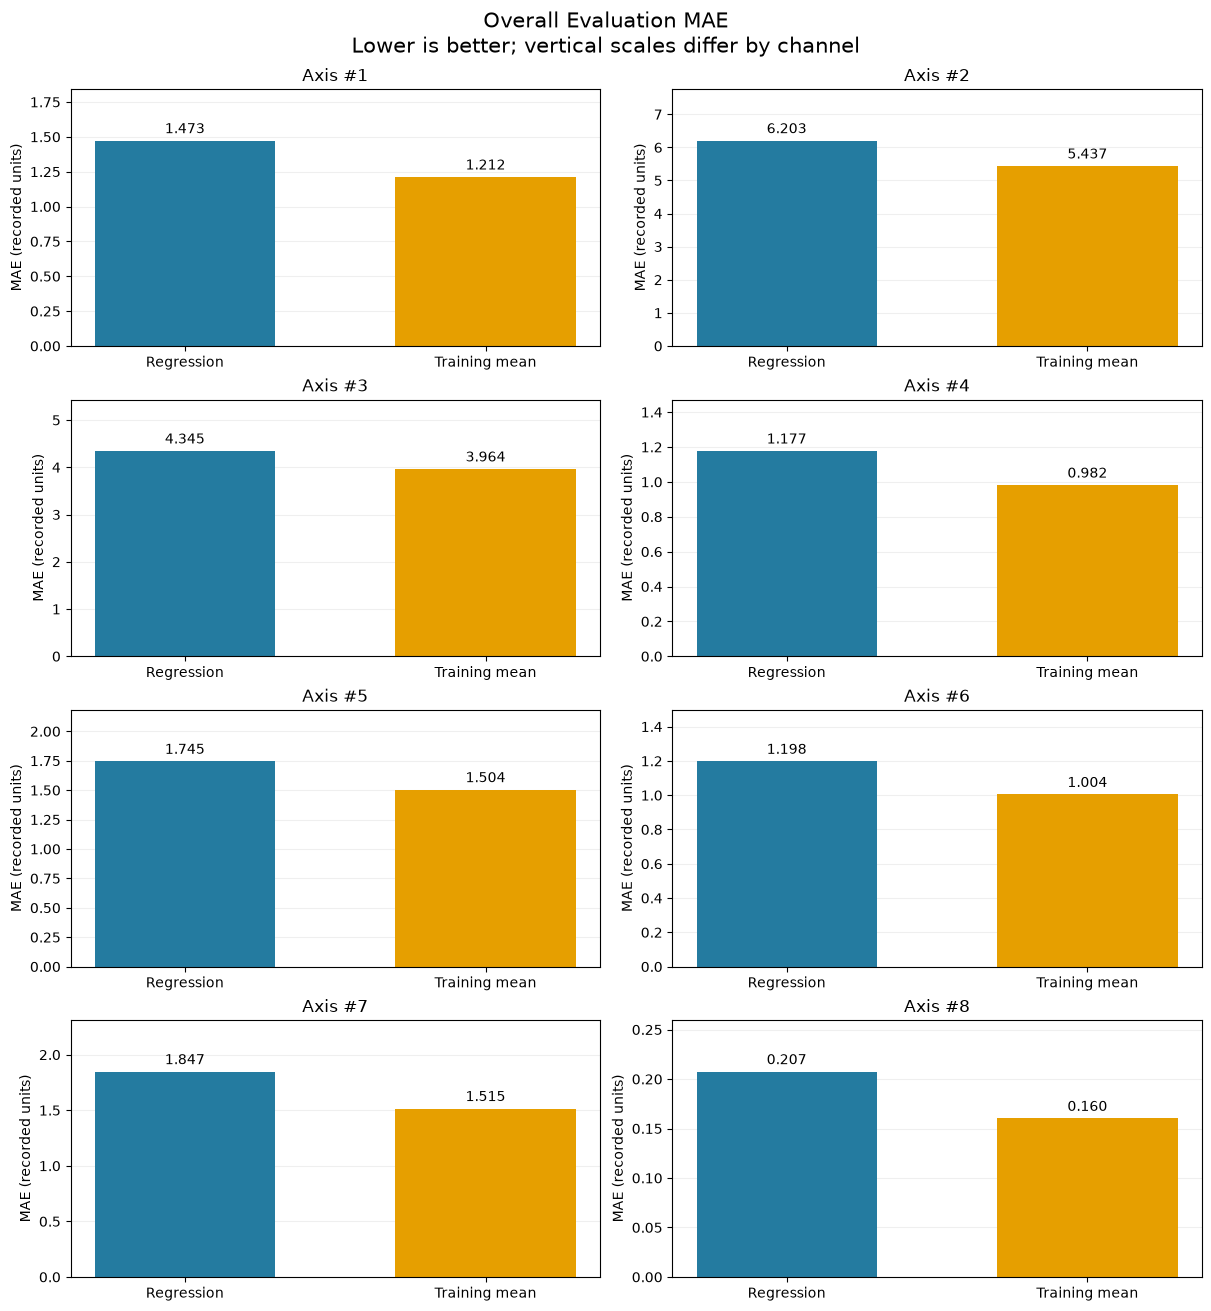

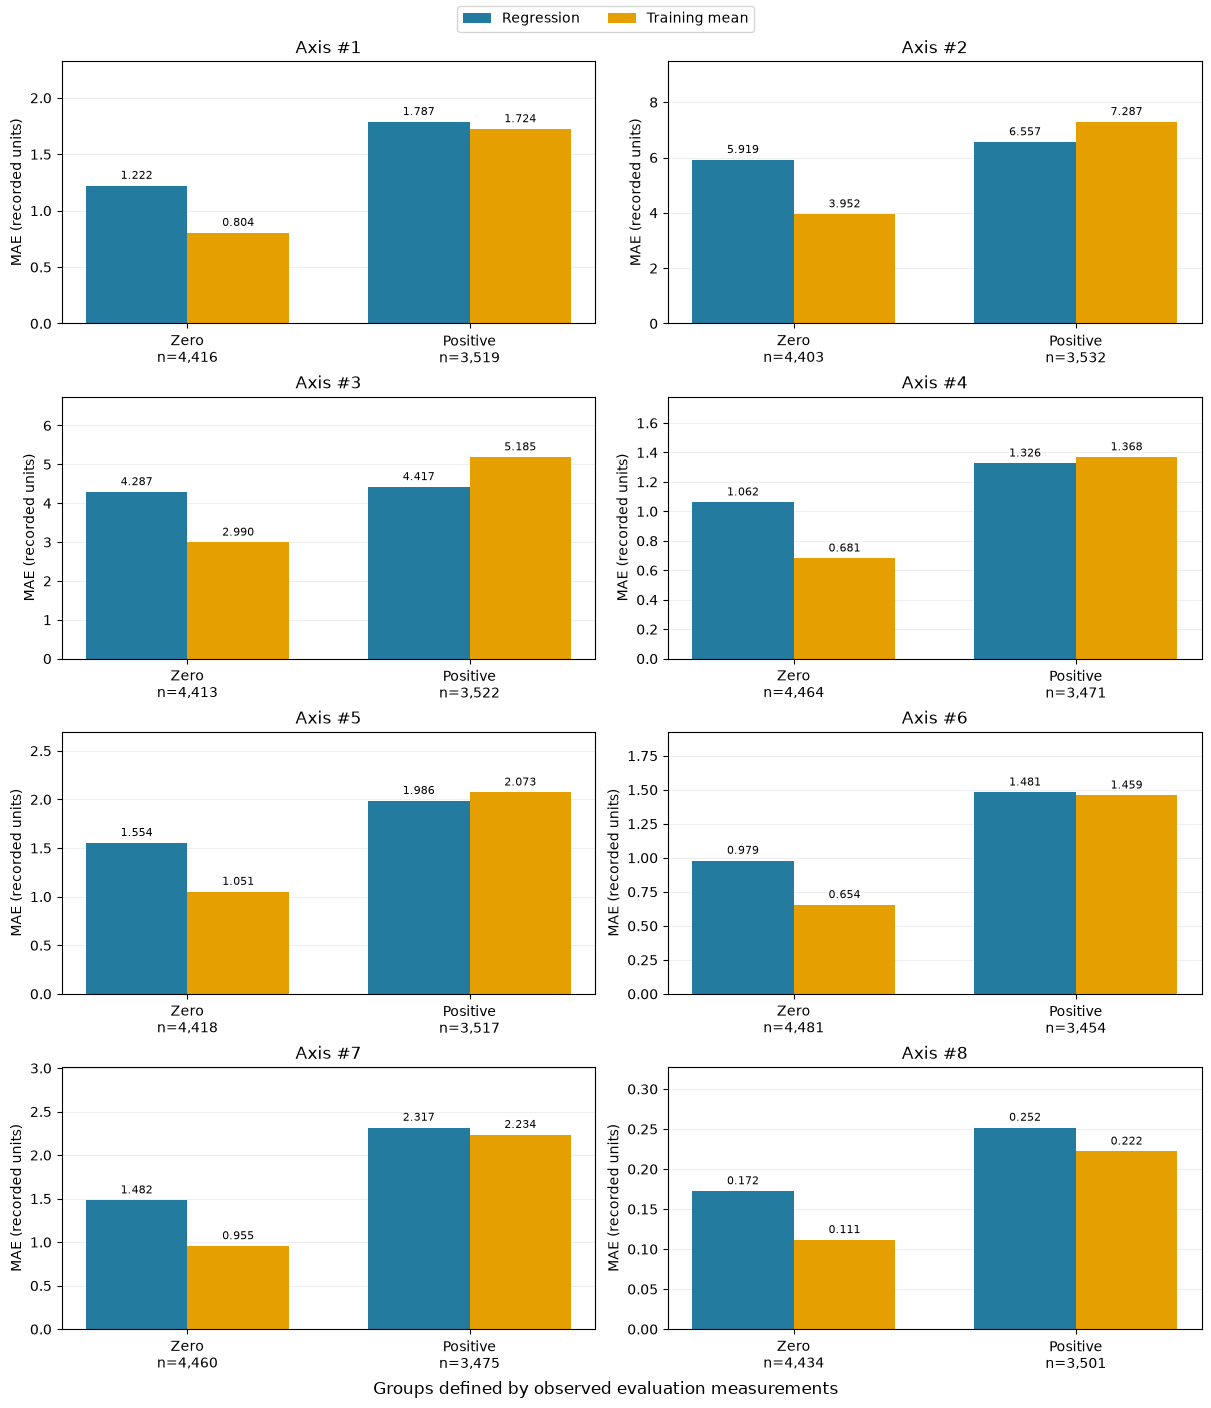

Two MAE comparison figures were saved.


In [8]:
figure_path = output_path / "figures"
figure_path.mkdir(parents=True, exist_ok=True)

method_colors = ["#247BA0", "#E69F00"]

# Figure 1: overall MAE, with one panel per channel.
fig, axes = plt.subplots(
    4, 2, figsize=(12, 13), constrained_layout=True
)

for ax, row in zip(axes.flat, mae_comparison.itertuples(index=False)):
    values = [row.regression_mae, row.mean_baseline_mae]

    bars = ax.bar(
        ["Regression", "Training mean"],
        values,
        color=method_colors,
        width=0.6,
    )

    ax.bar_label(bars, fmt="%.3f", padding=3)
    ax.set_title(row.channel)
    ax.set_ylabel("MAE (recorded units)")
    ax.set_ylim(0, max(values) * 1.25 if max(values) > 0 else 1)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

fig.suptitle(
    "Overall Evaluation MAE\n"
    "Lower is better; vertical scales differ by channel",
    fontsize=15,
)

fig.savefig(
    figure_path / "01_overall_mae_comparison.png",
    dpi=180,
)
plt.show()
plt.close(fig)

# Figure 2: group MAE, using only groups with observations.
fig, axes = plt.subplots(
    4, 2, figsize=(12, 14), constrained_layout=True
)

for axis, ax in zip(axis_columns, axes.flat):
    channel_results = group_mae_summary.loc[
        group_mae_summary["channel"].eq(axis)
        & group_mae_summary["count"].gt(0)
    ]

    counts = (
        channel_results.loc[
            channel_results["method"].eq("Linear regression")
        ]
        .set_index("observed_group")["count"]
    )

    groups = [
        group
        for group in ["Zero", "Positive", "Negative"]
        if group in counts.index
    ]
    positions = np.arange(len(groups))
    width = 0.36
    largest_mae = 0.0

    for offset, method, color, label in [
        (-width / 2, "Linear regression", method_colors[0], "Regression"),
        (width / 2, "Training-mean baseline", method_colors[1], "Training mean"),
    ]:
        values = (
            channel_results.loc[channel_results["method"].eq(method)]
            .set_index("observed_group")
            .loc[groups, "mae"]
            .to_numpy()
        )

        bars = ax.bar(
            positions + offset,
            values,
            width,
            color=color,
            label=label,
        )

        ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
        largest_mae = max(largest_mae, float(values.max()))

    ax.set_xticks(
        positions,
        [f"{group}\nn={int(counts[group]):,}" for group in groups],
    )
    ax.set_title(axis)
    ax.set_ylabel("MAE (recorded units)")
    ax.set_ylim(0, largest_mae * 1.3 if largest_mae > 0 else 1)
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper center", ncol=2)
fig.supxlabel("Groups defined by observed evaluation measurements")

fig.savefig(
    figure_path / "02_mae_by_observed_group.png",
    dpi=180,
)
plt.show()
plt.close(fig)

print("Two MAE comparison figures were saved.")

## 9. Interpret the Group Results

The mean baseline has lower overall MAE in all eight channels.
However, the overall comparison does not describe every observation group.

The following summary identifies which method has lower MAE within
each populated group. It also decomposes the overall difference:

    group contribution =
        group share × (regression group MAE − baseline group MAE)

A positive contribution increases the regression's overall disadvantage.
A negative contribution offsets that disadvantage.

Group contributions sum to the overall MAE difference. This explains
how group frequencies and group-specific errors combine.

These are retrospective comparisons within the existing evaluation
partition. They do not establish performance on unseen operating conditions.

In [9]:
# Compare methods within each populated observation group.
group_findings = group_comparison.copy()

group_findings["regression_minus_baseline_mae"] = (
    group_findings["Linear regression"]
    - group_findings["Training-mean baseline"]
)

group_findings["weighted_contribution"] = (
    group_findings["share_percent"] / 100
    * group_findings["regression_minus_baseline_mae"]
)

# Confirm that group contributions explain the overall MAE difference.
for axis in axis_columns:
    contributions = group_findings.loc[
        group_findings["channel"].eq(axis),
        "weighted_contribution",
    ].sum()

    overall = mae_comparison.loc[
        mae_comparison["channel"].eq(axis)
    ].iloc[0]

    np.testing.assert_allclose(
        contributions,
        overall["regression_mae"] - overall["mean_baseline_mae"],
        rtol=1e-12,
        atol=1e-12,
    )

for group in ["Zero", "Positive", "Negative"]:
    subset = group_findings.loc[
        group_findings["observed_group"].eq(group)
    ]

    if subset.empty:
        print(f"{group}: no evaluation observations.")
        continue

    difference = subset["regression_minus_baseline_mae"]
    equal = np.isclose(difference, 0, rtol=0, atol=1e-12)

    regression_wins = subset.loc[
        (difference < 0) & ~equal, "channel"
    ].tolist()
    baseline_wins = subset.loc[
        (difference > 0) & ~equal, "channel"
    ].tolist()
    ties = subset.loc[equal, "channel"].tolist()

    print(f"\nObserved group: {group}")
    print("Lower regression MAE:", ", ".join(regression_wins) or "None")
    print("Lower baseline MAE:", ", ".join(baseline_wins) or "None")
    print("Numerically equal:", ", ".join(ties) or "None")

group_findings.to_csv(
    output_path / "group_error_contributions.csv",
    index=False,
)

print("\nAxis 1: contribution to the overall MAE difference")
display(
    group_findings.loc[
        group_findings["channel"].eq("Axis #1"),
        [
            "observed_group",
            "count",
            "share_percent",
            "regression_minus_baseline_mae",
            "weighted_contribution",
        ],
    ].round(4)
)

print("PASS: group contributions reproduce all overall MAE differences.")


Observed group: Zero
Lower regression MAE: None
Lower baseline MAE: Axis #1, Axis #2, Axis #3, Axis #4, Axis #5, Axis #6, Axis #7, Axis #8
Numerically equal: None

Observed group: Positive
Lower regression MAE: Axis #2, Axis #3, Axis #4, Axis #5
Lower baseline MAE: Axis #1, Axis #6, Axis #7, Axis #8
Numerically equal: None
Negative: no evaluation observations.

Axis 1: contribution to the overall MAE difference


,observed_group,count,share_percent,regression_minus_baseline_mae,weighted_contribution
0,Positive,3519,44.3478,0.0631,0.0280
1,Zero,4416,55.6522,0.4177,0.2325


PASS: group contributions reproduce all overall MAE differences.


## 10. Conclusions and Practical Interpretation

### Main finding

The training-mean baseline achieves lower overall MAE in all eight
channels for this evaluation period.

For zero-valued observations, the baseline achieves lower MAE in
every channel.

For positive-valued observations, the regression achieves lower MAE
in Axes 2, 3, 4, and 5. The baseline achieves lower MAE in Axes 1, 6,
7, and 8. No negative-valued evaluation observations are present.

In Axes 2–5, the regression's improvement on positive observations
is outweighed by its larger errors on zero observations, accounting
for each group's sample count.

### Implications for Practical Lab 1

Elapsed time alone provides limited predictive value under this evaluation.
The comparison does not support claiming that the regression improves
overall MAE over the training-mean reference.

The original detector also uses residual thresholds and persistence rules.
Detecting a deliberately large synthetic deviation does not demonstrate
accurate prediction of ordinary measurements.

Replacing the regression with another predictor would change residuals
and require separate calibration and validation of the alert thresholds.
This extension does not make that replacement.

### Limitations

- The evaluation partition was previously examined; this is an exploratory
  extension rather than a new blind test.
- The results concern one recording and one chronological evaluation period.
- Physical measurement units and machine operating states are unverified.
- MAE does not report error direction, maximum error, or event duration.
- A low MAE does not establish mechanical fault-detection accuracy.
- Subgroup analysis uses observed outcomes and is retrospective.
- The mean baseline is a reference, not the best possible MAE baseline.
  A training-median baseline would be a useful future comparison.
- Differences are descriptive; statistical significance and operational
  importance have not been established.

### Practical guidance

Report overall MAE together with group counts and group-specific MAE.
Use the results to identify where further modeling work is needed.

Future evaluation could include a training-median baseline, additional
recordings, verified operating-state information, and labeled failures.
Any model changes should be assessed using an appropriate new evaluation
protocol rather than repeatedly optimizing against these same results.

## 11. Three Code Walkthrough Talking Points

### 1. Separate fitting from evaluation

Explain the chronological partition boundaries and why both the
regression and mean baseline use only fitting measurements.

Relevant sections: 2 and 3.

### 2. Calculate MAE and verify it independently

Explain the residual, absolute value, and averaging operations.
Show agreement between direct calculations and scikit-learn.

Relevant sections: 4 and 5.

### 3. Interpret overall and group-specific results

Explain why group frequencies affect overall MAE and how the weighted
contributions reproduce the overall difference between methods.

Relevant sections: 7 and 9.

## 12. Individual Self-Assessment

This section adapts the instructor's Code Walkthrough Peer Assessment
rubric to the approved individual format. No peer review is claimed.

**Author and self-reviewer:** Antonio Sainz  
**Selected method:** Mean Absolute Error (MAE)  
**Assessment status:** Provisional self-assessment for instructor review.

| Criterion | Evidence location | Self-score | Justification |
|---|---|---:|---|
| Code accuracy | Sections 2–5, 7, and 9; outputs/reproduction_check.json | 3/3 | Direct calculations match scikit-learn within explicit tolerances. Partition and weighted reconstruction checks pass. Execution was reproduced in a separate checkout and virtual environment. |
| Interpretation | Sections 6, 9, and 10 | 3/3 | Results are explained in recorded units, compared with a training-mean baseline, and examined by observed group. Limitations distinguish prediction error from fault detection. |
| Clarity of walkthrough | Section 11 and the reflection below | 2/3 | Three talking points are prepared. Further independent practice is needed to explain arbitrary code lines and weighted contributions confidently. |
| Evidence and transparency | Executed notebook, outputs/, README.md, and opening AI disclosure | 3/3 | Tables, figures, execution instructions, reproduction evidence, and AI assistance are documented. |

**Provisional total: 11/12.**

These scores are a self-assessment, not the instructor's final grade.
The clarity score reflects a remaining learning objective.

### One strength supported by evidence

Direct MAE calculations agree with scikit-learn. Additional checks
reconstruct overall MAE from group results and explain the overall
difference between the two prediction methods.

### One thing to improve

Strengthen the independent explanation of group weighting and its
implementation. A future analytical extension could compare a
training-median baseline and evaluate additional recordings.

### Line-by-line self-review question

Why is the overall MAE calculated as a count-weighted average of group
MAEs rather than the simple average of those group MAEs?

### Explanation developed during AI-assisted self-review

MAE is the average absolute error across individual observations.
Each observation receives equal weight.

When observations are divided into groups of different sizes, each
group's MAE must be weighted by its observation count. A simple average
of group MAEs would give equal weight to groups rather than observations.

For Axis 1, the evaluation partition contains 4,416 zero observations
and 3,519 positive observations:

    overall MAE =
        (4416 × zero-group MAE + 3519 × positive-group MAE) / 7935

These weights describe groups within Axis 1. They do not assign
importance to Axis 1 relative to other channels.

A weighted contribution measured in recorded units is not a percentage.
For example, a contribution of 0.23 recorded units does not mean 23%.

### Learning reflection

During the guided review, I initially confused weighted contributions
with percentages across channels. The explanation clarified that MAE
is the average absolute error and that group weighting preserves equal
weight for individual observations. Further practice is needed to
explain this distinction independently.

### Verification status

- Fresh-kernel interactive execution: Completed and confirmed by the author.
- Automated notebook execution and HTML export: Completed.
- Separate-checkout and fresh-environment reproduction: Completed.
- Reproduction evidence: outputs/reproduction_check.json.
- README setup and execution instructions: Documented.
- Independent oral explanation practice: In progress.